# 04 - Approximate Nearest Neighbor (ANN)


---

In the previous notebook, we learned Exact Search using KNN.

Exact Search always finds the true nearest neighbors.

But there is a problem.

When datasets become very large, Exact Search becomes slow.

Researchers solved this problem using Approximate Nearest Neighbor (ANN).

This notebook explains why ANN became the foundation of modern vector databases.

##  History

Early systems used Exact Search.

Every query compared against every vector.

This worked well for small datasets.

As datasets grew to millions and billions of vectors,

Exact Search became too slow.

Researchers asked:

"Can we make search much faster while still returning almost the same results?"

This idea became Approximate Nearest Neighbor (ANN).

##  Think Like a Researcher

Imagine a library with 10 books.

Finding the correct book is easy.

Now imagine a library with 100 million books.

Would you check every shelf?

No.

You first go to the correct section,

then the correct shelf,

then the correct book.

ANN works in a similar way.

It avoids searching everywhere.

In [1]:
documents = 1_000_000

comparisons = documents

print(f"Exact Search compares {comparisons:,} vectors.")

Exact Search compares 1,000,000 vectors.


##  ANN Idea

Exact Search

↓

Compare every vector

↓

100% accurate

↓

Slow

---

Approximate Search

↓

Skip many vectors

↓

Almost correct

↓

Much faster

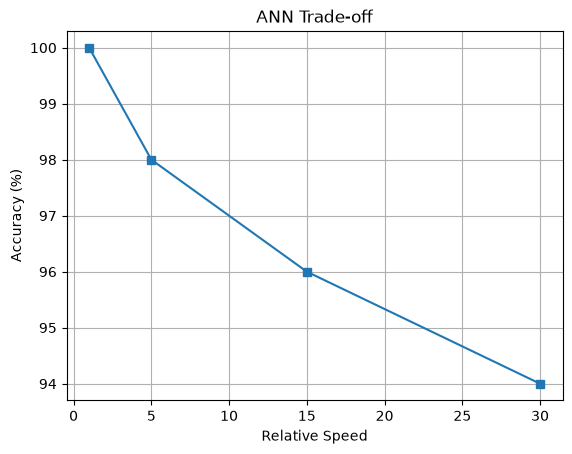

In [5]:
import matplotlib.pyplot as plt

accuracy = [100,98,96,94]

speed = [1,5,15,30]

plt.plot(speed,accuracy,marker="s")

plt.xlabel("Relative Speed")

plt.ylabel("Accuracy (%)")

plt.title("ANN Trade-off")

plt.grid()

plt.show()

## Observation

Researchers discovered something important.

Losing only

1–2%

accuracy

can make search

10–100×

faster.

This trade-off is acceptable in many AI applications.

In [6]:
exact_results = [
    "Document A",
    "Document B",
    "Document C"
]

ann_results = [
    "Document A",
    "Document C",
    "Document B"
]

print("Exact :",exact_results)

print("ANN :",ann_results)

Exact : ['Document A', 'Document B', 'Document C']
ANN : ['Document A', 'Document C', 'Document B']


## Discussion

Notice:

The results are slightly different,

but they are still highly relevant.

For applications like RAG,

this is usually good enough.

##  Recall

Recall measures

how many true neighbors were successfully found.

Example

Exact Search

↓

Top 10

ANN

↓

Found 9 of them

Recall

↓

90%

In [7]:
true_neighbors = {
    "A","B","C","D","E"
}

ann_neighbors = {
    "A","B","C","E"
}

recall = len(
    true_neighbors.intersection(
        ann_neighbors
    )
)/len(true_neighbors)

print(recall)

0.8


## Why ANN?

Imagine

1 billion vectors.

Exact Search

↓

1 billion comparisons.

ANN

↓

Search only a small subset.

Huge speed improvement.

##  Real Applications

ANN powers

- ChatGPT Retrieval
- RAG
- Recommendation Systems
- Image Search
- Face Recognition
- Video Search
- Music Search

## Popular ANN Algorithms

Many algorithms implement ANN.

Examples

- KDTree
- LSH
- IVF
- HNSW

Each uses a different strategy

to avoid searching every vector.

## Exact vs Approximate

| Feature | Exact Search | ANN |
|----------|--------------|-----|
| Accuracy | Highest | Very High |
| Speed | Slow | Fast |
| Memory | Moderate | Depends on index |
| Billion-scale Search | Difficult | Practical |
| Production Systems | Rare | Common |

## Production Systems

Modern vector databases such as

- FAISS
- Qdrant
- Milvus
- Pinecone

use ANN internally.

Searching billions of vectors exactly

would be too slow.

## Advantages

✅ Very fast

✅ Scales well

✅ Handles large datasets

✅ High recall

✅ Production ready

## Limitations

❌ May miss the exact nearest vector

❌ Accuracy depends on the index

❌ Requires tuning parameters

##  Summary

Today I learned:

- Why ANN exists
- Exact vs Approximate Search
- Accuracy vs Speed
- Recall
- Production use cases

##  Think Like a Researcher


Now we know

why ANN exists.

But another question appears.

How can we reduce the number of vectors we search?

One simple idea is

to group similar vectors together.

Instead of searching the whole database,

we search only inside one group.

This idea is called

**Clustering**.